In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

<Axes: title={'center': 'temp anual'}>

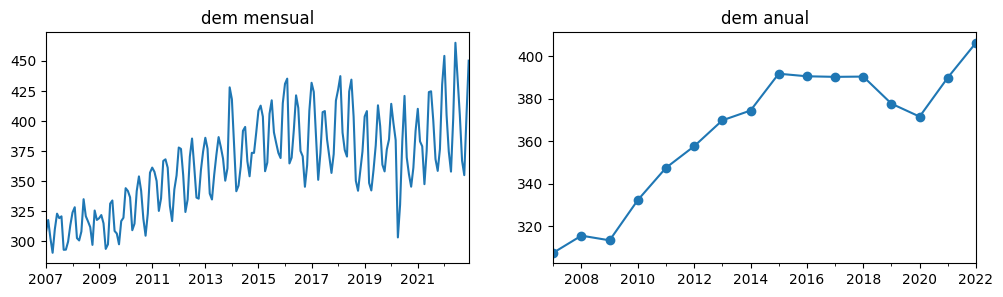

<Figure size 200x200 with 0 Axes>

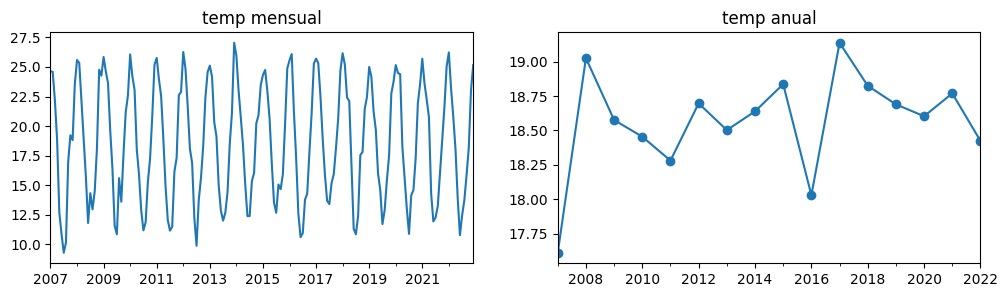

<Figure size 200x200 with 0 Axes>

In [27]:
# serie emi temp
dft=pd.read_csv('temp-arg.txt', sep=';', header=None, names=['year', 'month', 'day', 'value'])
temp=dft.set_index(pd.to_datetime(dft[['year', 'month', 'day']]) )['value']
# serie emi demanda
dfd = pd.read_csv('arg-dem.txt', sep=';', header=None, names=['year', 'month', 'day', 'value'])
dem=dfd.set_index(pd.to_datetime(dfd[['year', 'month', 'day']]))['value']
# muestra
fig, ax = plt.subplots(1,2, figsize=(12,3))
dem.resample('ME').mean().plot(style='-',ax=ax[0],title='dem mensual')
plt.figure(figsize=(2,2)) # (otra figura)
dem.resample('YE').mean().plot(style='-o',ax=ax[1],title='dem anual')
fig, ax = plt.subplots(1,2, figsize=(12,3))
temp.resample('ME').mean().plot(style='-',ax=ax[0],title='temp mensual')
plt.figure(figsize=(2,2)) # (otra figura)
temp.resample('YE').mean().plot(style='-o',ax=ax[1],title='temp anual')



aguante claude

$$demand(t) = a_0 + a_1 \cdot t + a_2 \cdot hdd(t) + a_3 \cdot cdd(t) $$ <!-- + \sum_{i=4}^{10} a_i \cdot d_i(t)$$ -->

4 parámetros en total:

| parámetro | variable |
|---|---|
| `a_0` | intercept |
| `a_1` | tendencia lineal |
| `a_2` | hdd |
| `a_3` | cdd |

**X** tiene 4 columnas, **n** filas (un día por fila):

$$\mathbf{X} = \begin{bmatrix} 1 & 1 & hdd_1 & cdd_1 \\ 1 & 2 & hdd_2 & cdd_2 \\ \vdots & \vdots & \vdots & \vdots \\ 1 & n & hdd_n & cdd_n \end{bmatrix} \qquad \boldsymbol{\beta} = \begin{bmatrix} a_0 \\ a_1 \\ a_2 \\ a_3 \end{bmatrix} \qquad \mathbf{y} = \begin{bmatrix} dem_1 \\ dem_2 \\ \vdots \\ dem_n \end{bmatrix}$$

Y resolvés:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

Uso `np.linalg.solve` en lugar de invertir explícitamente — es más estable numéricamente.


In [97]:
# preparo dataframes que necesito
T_base_hdd = 15.5
T_base_cdd = 22.0

df = pd.DataFrame()
df['dem'] = dem
df['temp'] = temp 
df['hdd'] = (T_base_hdd - temp).clip(lower=0)
df['cdd'] = (temp - T_base_cdd).clip(lower=0)
df['t'] = np.arange(len(df))
df['cero'] = np.ones(len(df))


df = df.loc[(df.index.year > 2016) & (df.index.year < 2020)]

[ 4.67233437e+02 -2.37509488e-02  9.91493361e-01]
[ 4.41481823e+02 -1.99043950e-02  1.24163188e+01  1.56342602e+01]
[ 4.43911096e+02 -2.01385688e-02  1.19560315e+01  1.50303262e+01
  9.41530037e+00  1.56680412e+01  1.82761599e+01  1.52144676e+01
 -1.66009423e+01 -4.43479533e+01]
[-7.15243686e+03 -2.01385688e-02  1.19560315e+01  1.50303262e+01
  7.59634795e+03  7.60576325e+03  7.61201599e+03  7.61462411e+03
  7.61156242e+03  7.57974701e+03  7.55200000e+03]


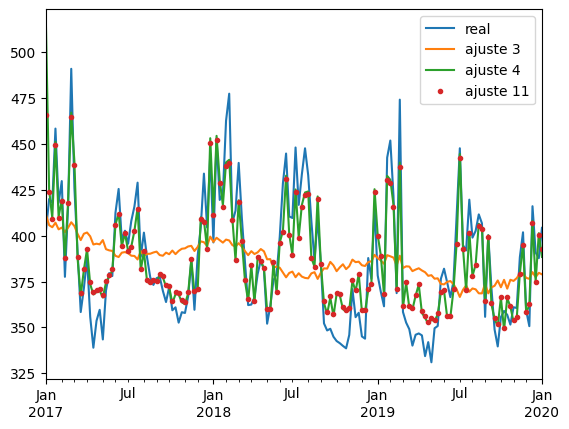

In [141]:
X = df[['cero','t','temp']].values
y = df['dem'].values
beta = np.linalg.solve(X.T @ X, X.T @ y)
df['dem3']=X@beta
print(beta)

X = df[['cero','t', 'hdd', 'cdd']].values
y = df['dem'].values
beta = np.linalg.solve(X.T @ X, X.T @ y)
df['dem4']=X@beta
print(beta)

dummies = pd.get_dummies(df.index.dayofweek, prefix='dow', drop_first=True)
dummies.set_index(df.index, inplace = True)
X = np.concat([
    df[['cero','t', 'hdd', 'cdd']],
    dummies.values
], axis=1)
y = df['dem'].values
# print(X.shape, y.shape)
beta = np.linalg.solve(X.T @ X, X.T @ y)
df['dem10']=X@beta
print(beta)

dummies = pd.get_dummies(df.index.dayofweek, prefix='dow')#, drop_first=True)
dummies.set_index(df.index, inplace = True)
X = np.concat([
    df[['cero','t', 'hdd', 'cdd']],
    dummies.values
], axis=1)
y = df['dem'].values
# print(X.shape, y.shape)
beta = np.linalg.solve(X.T @ X, X.T @ y)
df['dem11']=X@beta
print(beta)

df['dem'].resample('W').mean().plot(label = 'real')
df['dem3'].resample('W').mean().plot(label = 'ajuste 3')
df['dem4'].resample('W').mean().plot(label = 'ajuste 4')
df['dem11'].resample('W').mean().plot(style = '.',label = 'ajuste 11')

plt.legend()

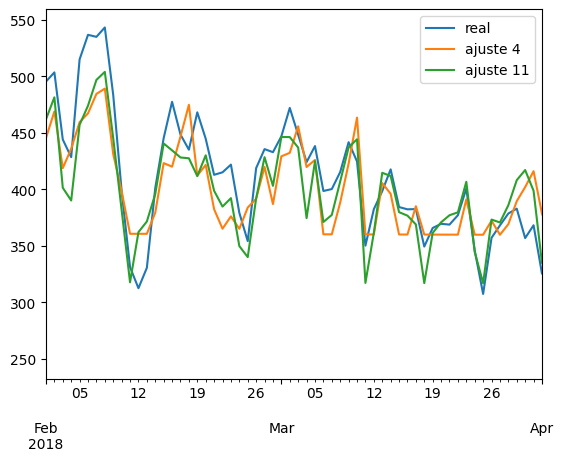

In [138]:

df['dem'].plot(label = 'real')
df['dem4'].plot(label = 'ajuste 4')
df['dem11'].plot(label = 'ajuste 11')

plt.xlim(left='20180201', right='20180401')
plt.legend()